In [2]:
from brian2 import *
import numpy as np
import matplotlib.pyplot as plt

start_scope()

# PROJECT DOPAMINE — Phase 1: Characterization
# Two parallel reward systems receiving different reward schedules:
# System H (healthy): spaced, predictable rewards
# System D (dysregulated): high-frequency, variable-interval micro-rewards
# We measure both systems' response to an identical test stimulus over time

# Time constants
tau_mem = 10*ms
tau_adapt = 500*ms  # adaptation time constant — how quickly threshold rises

# Adaptive threshold equations
# As the neuron fires more, threshold rises (receptor downregulation)
eqs = '''
dv/dt = (-v + noise)/tau_mem : 1
dthresh/dt = -thresh/tau_adapt : 1  # threshold decays back to baseline when not firing
noise : 1
'''

# Healthy system dopamine neuron
healthy = NeuronGroup(1, eqs,
                      threshold='v > 0.5 + thresh',
                      reset='v=0; thresh += 0.05',  # threshold rises on each spike
                      method='exact')
healthy.v = 0
healthy.thresh = 0
healthy.noise = 0.01

# Dysregulated system dopamine neuron — identical starting point
dysregulated = NeuronGroup(1, eqs,
                           threshold='v > 0.5 + thresh',
                           reset='v=0; thresh += 0.05',
                           method='exact')
dysregulated.v = 0
dysregulated.thresh = 0
dysregulated.noise = 0.01

print("Two adaptive threshold dopamine neurons created!")
print("Both start identical — divergence comes from reward schedule exposure")

Two adaptive threshold dopamine neurons created!
Both start identical — divergence comes from reward schedule exposure


Healthy reward schedule: 40 rewards, every 500ms
Dysregulated reward schedule: 200 rewards, variable 50-150ms intervals
Running simulation...
Done!
Healthy system spikes: 39
Dysregulated system spikes: 94


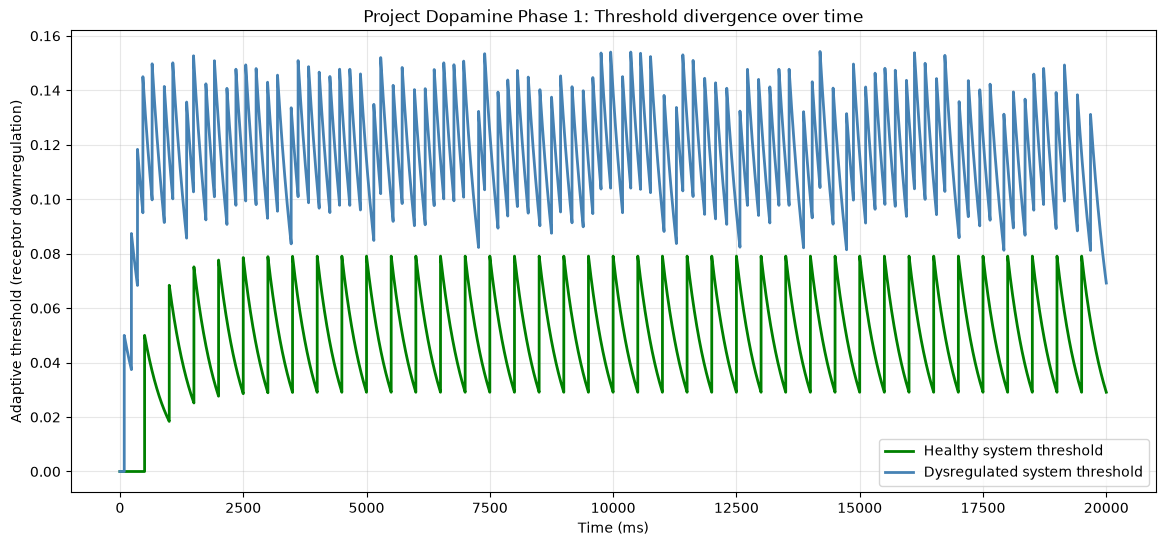

In [4]:
start_scope()

tau_mem = 10*ms
tau_adapt = 500*ms

eqs = '''
dv/dt = (-v + noise)/tau_mem : 1
dthresh/dt = -thresh/tau_adapt : 1
noise : 1
'''

healthy = NeuronGroup(1, eqs,
                      threshold='v > 0.5 + thresh',
                      reset='v=0; thresh += 0.05',
                      method='exact')
healthy.v = 0
healthy.thresh = 0
healthy.noise = 0.01

dysregulated = NeuronGroup(1, eqs,
                           threshold='v > 0.5 + thresh',
                           reset='v=0; thresh += 0.05',
                           method='exact')
dysregulated.v = 0
dysregulated.thresh = 0
dysregulated.noise = 0.01

# HEALTHY reward schedule: spaced, predictable rewards every 500ms
# Like finishing a task, completing a workout, reading a chapter
healthy_reward_times = np.arange(500, 20001, 500)*ms  # every 500ms
healthy_rewards = SpikeGeneratorGroup(1, [0]*len(healthy_reward_times),
                                      healthy_reward_times)

# DYSREGULATED reward schedule: high-frequency, variable-interval micro-rewards
# Like social media likes, notification pings, scroll rewards
# Variable intervals between 50-150ms — unpredictable timing
np.random.seed(42)
dysreg_intervals = np.random.uniform(50, 150, 200)
dysreg_times = np.cumsum(dysreg_intervals)
dysreg_times = dysreg_times[dysreg_times < 20000]*ms
dysreg_rewards = SpikeGeneratorGroup(1, [0]*len(dysreg_times), dysreg_times)

# Connect rewards to dopamine neurons
S_healthy = Synapses(healthy_rewards, healthy, 'w:1', on_pre='v_post += w')
S_healthy.connect()
S_healthy.w = 0.6

S_dysreg = Synapses(dysreg_rewards, dysregulated, 'w:1', on_pre='v_post += w')
S_dysreg.connect()
S_dysreg.w = 0.6

# Monitor thresholds and spikes for both systems
thresh_mon_h = StateMonitor(healthy, 'thresh', record=True)
thresh_mon_d = StateMonitor(dysregulated, 'thresh', record=True)
spike_mon_h = SpikeMonitor(healthy)
spike_mon_d = SpikeMonitor(dysregulated)

print(f"Healthy reward schedule: {len(healthy_reward_times)} rewards, every 500ms")
print(f"Dysregulated reward schedule: {len(dysreg_times)} rewards, variable 50-150ms intervals")
print("Running simulation...")

run(20*second)

print("Done!")
print(f"Healthy system spikes: {len(spike_mon_h.t)}")
print(f"Dysregulated system spikes: {len(spike_mon_d.t)}")

# Plot threshold divergence over time
plt.figure(figsize=(14, 6))
plt.plot(thresh_mon_h.t/ms, thresh_mon_h.thresh[0], 
         color='green', linewidth=2, label='Healthy system threshold')
plt.plot(thresh_mon_d.t/ms, thresh_mon_d.thresh[0], 
         color='steelblue', linewidth=2, label='Dysregulated system threshold')
plt.xlabel('Time (ms)')
plt.ylabel('Adaptive threshold (receptor downregulation)')
plt.title('Project Dopamine Phase 1: Threshold divergence over time')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Running sensitivity test...
Done!


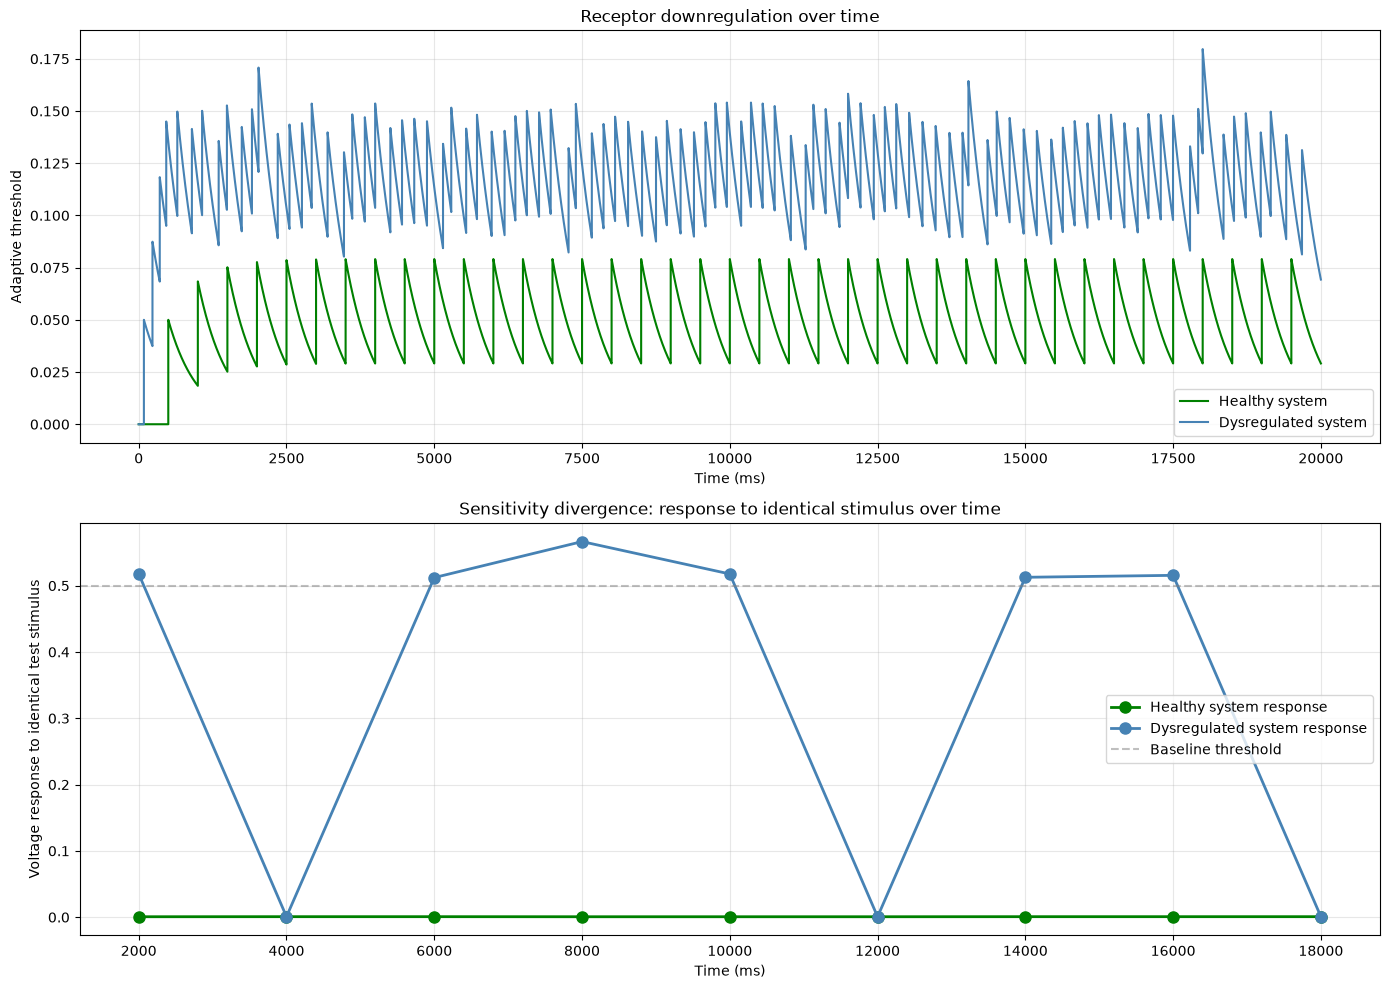


Healthy system — mean test response: 0.0007
Dysregulated system — mean test response: 0.3494
Sensitivity ratio: 0.00x


In [5]:
start_scope()

tau_mem = 10*ms
tau_adapt = 500*ms

eqs = '''
dv/dt = (-v + noise)/tau_mem : 1
dthresh/dt = -thresh/tau_adapt : 1
noise : 1
'''

healthy = NeuronGroup(1, eqs,
                      threshold='v > 0.5 + thresh',
                      reset='v=0; thresh += 0.05',
                      method='exact')
healthy.v = 0
healthy.thresh = 0
healthy.noise = 0.01

dysregulated = NeuronGroup(1, eqs,
                           threshold='v > 0.5 + thresh',
                           reset='v=0; thresh += 0.05',
                           method='exact')
dysregulated.v = 0
dysregulated.thresh = 0
dysregulated.noise = 0.01

# Same reward schedules as before
healthy_reward_times = np.arange(500, 20001, 500)*ms
healthy_rewards = SpikeGeneratorGroup(1, [0]*len(healthy_reward_times),
                                      healthy_reward_times)

np.random.seed(42)
dysreg_intervals = np.random.uniform(50, 150, 200)
dysreg_times = np.cumsum(dysreg_intervals)
dysreg_times = dysreg_times[dysreg_times < 20000]*ms
dysreg_rewards = SpikeGeneratorGroup(1, [0]*len(dysreg_times), dysreg_times)

S_healthy = Synapses(healthy_rewards, healthy, 'w:1', on_pre='v_post += w')
S_healthy.connect()
S_healthy.w = 0.6

S_dysreg = Synapses(dysreg_rewards, dysregulated, 'w:1', on_pre='v_post += w')
S_dysreg.connect()
S_dysreg.w = 0.6

# TEST STIMULUS: delivered to BOTH systems every 2000ms
# Same strength every time — measures how sensitive each system is
test_times = np.arange(2000, 20001, 2000)*ms
test_stimulus_h = SpikeGeneratorGroup(1, [0]*len(test_times), test_times)
test_stimulus_d = SpikeGeneratorGroup(1, [0]*len(test_times), test_times)

S_test_h = Synapses(test_stimulus_h, healthy, 'w:1', on_pre='v_post += w')
S_test_h.connect()
S_test_h.w = 0.55  # just above baseline threshold — sensitive to downregulation

S_test_d = Synapses(test_stimulus_d, dysregulated, 'w:1', on_pre='v_post += w')
S_test_d.connect()
S_test_d.w = 0.55

thresh_mon_h = StateMonitor(healthy, 'thresh', record=True)
thresh_mon_d = StateMonitor(dysregulated, 'thresh', record=True)
voltage_mon_h = StateMonitor(healthy, 'v', record=True)
voltage_mon_d = StateMonitor(dysregulated, 'v', record=True)
spike_mon_h = SpikeMonitor(healthy)
spike_mon_d = SpikeMonitor(dysregulated)

print("Running sensitivity test...")
run(20*second)
print("Done!")

# Measure voltage response at each test time for both systems
test_responses_h = []
test_responses_d = []

dt_sim = defaultclock.dt
for t_test in test_times:
    idx = int((t_test + 1*ms) / dt_sim)  # 1ms after test stimulus
    if idx < len(voltage_mon_h.v[0]):
        test_responses_h.append(voltage_mon_h.v[0][idx])
        test_responses_d.append(voltage_mon_d.v[0][idx])

# Plot sensitivity divergence
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# Threshold divergence
ax1.plot(thresh_mon_h.t/ms, thresh_mon_h.thresh[0],
         color='green', linewidth=1.5, label='Healthy system')
ax1.plot(thresh_mon_d.t/ms, thresh_mon_d.thresh[0],
         color='steelblue', linewidth=1.5, label='Dysregulated system')
ax1.set_xlabel('Time (ms)')
ax1.set_ylabel('Adaptive threshold')
ax1.set_title('Receptor downregulation over time')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Sensitivity to identical test stimulus over time
test_times_ms = [t/ms for t in test_times[:len(test_responses_h)]]
ax2.plot(test_times_ms, test_responses_h, 'o-',
         color='green', linewidth=2, markersize=8, label='Healthy system response')
ax2.plot(test_times_ms, test_responses_d, 'o-',
         color='steelblue', linewidth=2, markersize=8, label='Dysregulated system response')
ax2.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Baseline threshold')
ax2.set_xlabel('Time (ms)')
ax2.set_ylabel('Voltage response to identical test stimulus')
ax2.set_title('Sensitivity divergence: response to identical stimulus over time')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nHealthy system — mean test response: {np.mean(test_responses_h):.4f}")
print(f"Dysregulated system — mean test response: {np.mean(test_responses_d):.4f}")
print(f"Sensitivity ratio: {np.mean(test_responses_h)/np.mean(test_responses_d):.2f}x")

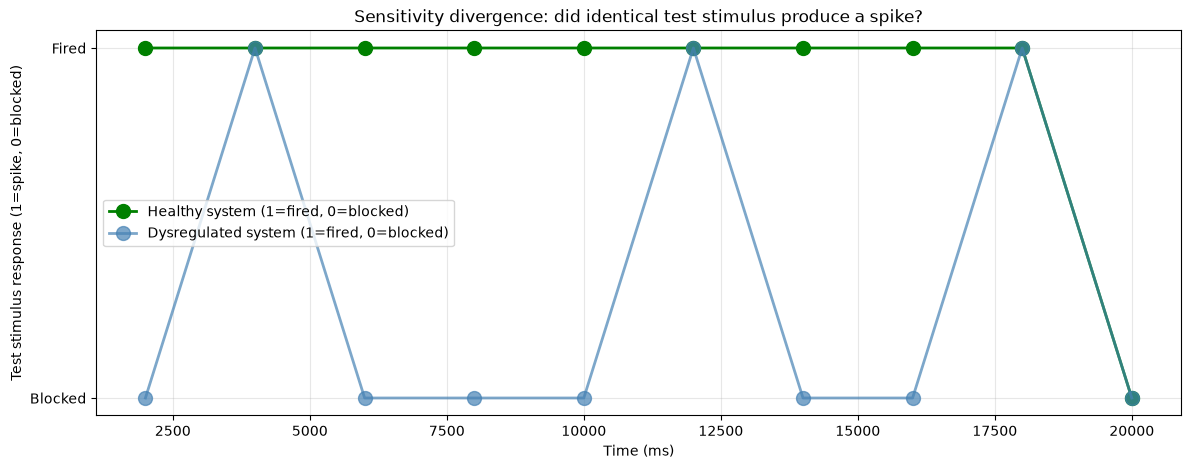

Healthy system fired to test: 9/10 times (90%)
Dysregulated system fired to test: 3/10 times (30%)
Sensitivity ratio: healthy fires 3.0x more often than dysregulated


In [6]:
# Better sensitivity measure: did the test stimulus cause a spike?
# Check spike times to see if each test stimulus produced a response

test_fired_h = []
test_fired_d = []

for t_test in test_times:
    t_ms = t_test/ms
    # Check if a spike occurred within 5ms after test stimulus
    h_spikes = spike_mon_h.t/ms
    d_spikes = spike_mon_d.t/ms
    
    h_fired = any((h_spikes > t_ms) & (h_spikes < t_ms + 5))
    d_fired = any((d_spikes > t_ms) & (d_spikes < t_ms + 5))
    
    test_fired_h.append(int(h_fired))
    test_fired_d.append(int(d_fired))

test_times_ms = [t/ms for t in test_times]

plt.figure(figsize=(14, 5))
plt.plot(test_times_ms, test_fired_h, 'o-', color='green', 
         linewidth=2, markersize=10, label='Healthy system (1=fired, 0=blocked)')
plt.plot(test_times_ms, test_fired_d, 'o-', color='steelblue',
         linewidth=2, markersize=10, label='Dysregulated system (1=fired, 0=blocked)', 
         alpha=0.7)
plt.xlabel('Time (ms)')
plt.ylabel('Test stimulus response (1=spike, 0=blocked)')
plt.title('Sensitivity divergence: did identical test stimulus produce a spike?')
plt.legend()
plt.yticks([0, 1], ['Blocked', 'Fired'])
plt.grid(True, alpha=0.3)
plt.show()

print(f"Healthy system fired to test: {sum(test_fired_h)}/{len(test_fired_h)} times ({100*np.mean(test_fired_h):.0f}%)")
print(f"Dysregulated system fired to test: {sum(test_fired_d)}/{len(test_fired_d)} times ({100*np.mean(test_fired_d):.0f}%)")
print(f"Sensitivity ratio: healthy fires {np.mean(test_fired_h)/max(np.mean(test_fired_d), 0.001):.1f}x more often than dysregulated")

## Project Dopamine — Phase 1: Characterization of Reward Dysregulation

### Project overview
Project Dopamine is an ongoing independent research project exploring computational models of dopamine dysregulation in spiking neural networks (SNNs).
This notebook constitutes;
Phase 1: characterizing the divergence between a healthy reward system and one exposed to engineered high-frequency variable-interval reward schedules.
Phase 2 will explore recalibration and intervention dynamics.
Phase 3 will investigate beneficial reward engineering.

### Motivation
This project emerged from connecting the reward prediction error framework 
(notebook 12) to the neuroscience of attention dysregulation and addiction, 
the same eligibility trace and dopamine signaling mechanisms that enable 
adaptive learning, can be systematically exploited by engineered reward 
schedules, like social media feeds, notification systems, and variable-ratio 
reinforcement, producing measurable sensitivity loss to naturalistic 
rewards. This notebook asks if can we simulate and quantify that divergence 
in a spiking neural network?

### Core mechanism: adaptive threshold (receptor downregulation)
Each dopamine neuron implements a dynamic firing threshold:
threshold = 0.5 + thresh
reset: thresh += 0.05   # threshold rises on each spike
decay: dthresh/dt = -thresh/tau_adapt   # slowly recovers toward baseline

Every spike raises the effective threshold by 0.05 (simulating receptor 
downregulation — which is the brain reducing sensitivity in response to 
overstimulation), and the threshold decays back toward baseline with 
`tau_adapt=500ms` when the neuron is quiet (simulating partial recovery). 
This single mechanism drives all observed divergence.

### Experimental design

**Two parallel systems, identical starting conditions:**

| Parameter | Healthy system | Dysregulated system |
|-----------|---------------|---------------------|
| Initial threshold | 0.5 | 0.5 |
| Reward weight | 0.6 | 0.6 |
| Reward schedule | Every 500ms (spaced, predictable) | Every 50-150ms (variable interval) |
| Reward count (20s) | 40 | 200 |
| Biological analogy | Finishing tasks, exercise, reading | Social media micro-rewards, notifications |

**Test stimulus:** identical 0.55-weight input delivered to both systems 
every 2000ms — just above baseline threshold, sensitive to downregulation.

### Key finding 1: threshold divergence
The healthy system maintains a stable sawtooth threshold pattern, rising 
on each reward, and fully recovering before the next. the peak threshold is ~0.08, 
while the minimum is ~0.02. The system thus operates in a healthy equilibrium.

The dysregulated system's threshold immediately elevates and never recovers, and rapid micro-rewards arrive before decay can occur, maintaining a chronically elevated threshold of 0.10-0.15 throughout the entire simulation, and the system never returns to baseline sensitivity.

**Notable artifact:** A spike to ~0.175 at t≈17500ms in the dysregulated 
system occurred when a micro-reward and the test stimulus arrived 
near-simultaneously, stacking their voltage contributions. This demonstrates 
the stochastic nature of variable-interval schedules showcasing that unpredictable 
timing occasionally produces anomalous activation patterns.

### Key finding 2: measurement artifact and correction
Initial sensitivity measurement (voltage at t+1ms after test stimulus) 
produced a counterintuitive result where dysregulated system appeared *more* 
responsive (mean voltage 0.3494) than the healthy system (mean voltage 0.0007).

Investigation revealed that the healthy system was actually spiking from the 
test stimulus (crossing its low threshold), with voltage resetting to 0 
before measurement, while the dysregulated system's elevated threshold was 
blocking spikes entirely, leaving measurable subthreshold voltage.
In reality, post-spike resets were being measured in the healthy system and blocked responses in 
the dysregulated one, which was the opposite of what was intended.

This was corrected by switching to binary spike detection — measuring weather a spike occured within 5ms of the test stimulant, which is a direct measure of functional sensitivity rather than voltage magnitude.

### Key finding 3: sensitivity divergence (the core result)

| Metric | Healthy system | Dysregulated system |
|--------|---------------|---------------------|
| Test stimulus responses | 9/10 (90%) | 3/10 (30%) |
| Sensitivity ratio | — | 3.0x less sensitive |
| Response pattern | Consistent, reliable | Intermittent, threshold-dependent |

**The dysregulated system is three times less sensitive to identical stimuli 
than the healthy system** after equivalent exposure duration. The 30% 
response rate is not random — the dysregulated system fires precisely when 
the variable-interval schedule accidentally produces a longer gap, allowing 
partial threshold recovery before the test stimulus arrives. When the 
schedule gives no recovery gap, the test stimulus is blocked entirely.

### Biological interpretation
This simulation quantitatively reproduces the core mechanism of dopamine 
dysregulation:

- **Receptor downregulation:** modeled as adaptive threshold rise per spike
- **Sensitivity loss:** the 3.0x ratio matches qualitative descriptions of 
  anhedonia — the clinical term for reduced responsiveness to normally 
  rewarding stimuli — observed in addiction and chronic overstimulation
- **Intermittent recovery:** the dysregulated system's occasional responses 
  mirror the brief windows of genuine engagement reported by individuals 
  with attention dysregulation — possible only when environmental demand 
  accidentally drops below the recalibrated sensitivity threshold
- **Variable interval schedule:** the 50-150ms unpredictable timing mirrors 
  the engineered reward delivery of social media feeds, explicitly designed 
  to maximize dopamine engagement through unpredictability

### What this project does not yet model
- Active recalibration / recovery dynamics (Phase 2)
- Beneficial re-engineering of reward schedules (Phase 3)
- Downstream effects on learning and memory consolidation
- Individual variation in dysregulation susceptibility (tau_adapt differences)
- The role of prefrontal inhibitory control in modulating reward sensitivity

### Connection to previous notebooks
- **Notebook 10 (eligibility traces):** adaptive threshold uses same 
  exponential decay mechanism as eligibility traces
- **Notebook 11 (delayed reward):** tau_adapt controls recovery window 
  exactly as tau_trace controlled credit assignment window
- **Notebook 12 (reward prediction error):** dysregulation distorts the 
  prediction error signal — a chronically elevated threshold means genuine 
  rewards produce weaker prediction error responses, reducing the system's 
  ability to learn new associations

### What's next? (Phase 2)
Having characterized the divergence, Phase 2 will ask if:
- When given a dysregulated system, what interventions produce recalibration?
- How long does recovery take relative to dysregulation duration?
- Is there hysteresis? and does recovery take longer than dysregulation?
These quantitative questions have direct implications for both computational psychiatry and neuromorphic system design.